# Graph Benchmarks Notebook

Author: Chris Hinkson @cmh02

Project: Project 3 - AUBatch

Class: COMP7500 - Advanced Operating Systems

## Import Libraries

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Load CSV File

This section will load the CSV file for the notebook to use.

In [34]:
# Final results csv path
BENCHMARK_RESULTS_CSV="aubatch_benchmarks_final.csv"

# Load CSV w pandas to df
df = pd.read_csv(BENCHMARK_RESULTS_CSV, header=0)

## Policy Grouping

To compare policies, we first must group our data by policy. We can then take a look at means for each policy across the different metrics.

In [35]:
# Group by policy column
df_grouped = df.groupby("Scheduling Policy")

# Calculate means for each group
df_grouped_means = df_grouped.mean(numeric_only=True)

In [36]:
# Display table
print(df_grouped_means)

                   Number of Jobs  Arrival Rate  Number of Priority Levels  \
Scheduling Policy                                                            
FCFS                    13.187500      0.527500                   2.975000   
PRIORITY                13.037975      0.521519                   2.949367   
SJF                     13.187500      0.527500                   2.975000   

                   Min CPU Time  Max CPU Time  Total Seen Jobs  \
Scheduling Policy                                                
FCFS                   0.527500      3.756250        13.187500   
PRIORITY               0.527848      3.791139        13.037975   
SJF                    0.527500      3.756250        13.187500   

                   Average Turnaround Time  Average CPU Time  \
Scheduling Policy                                              
FCFS                             18.975000          3.089750   
PRIORITY                         19.517215          3.200759   
SJF                   

## Plot Turnaround vs Throughput

Next we can take a look at turnaround vs throughput for each group. I'll plot all the data and include a few trend lines for each group.

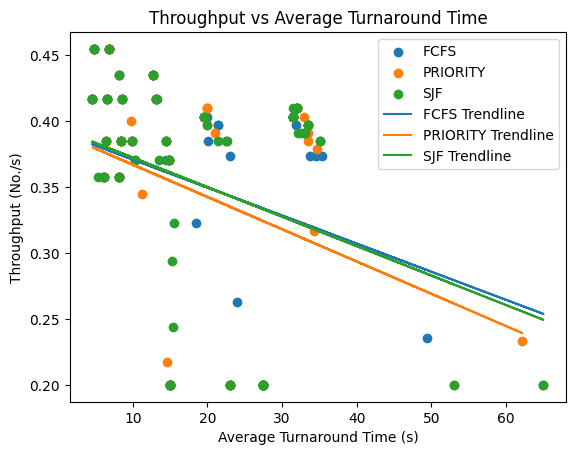

In [37]:
# Plot each group
for policy, policyData in df_grouped:
	plt.scatter(
		x=policyData["Average Turnaround Time"],
		y=policyData["Throughput"],
		label=policy
	)

# Trendlines
for policy, policyData in df_grouped:
	policydf = df_grouped.get_group(policy)
	x = policydf["Average Turnaround Time"]
	y = policydf["Throughput"]
	m, b = np.polyfit(x, y, 1)
	plt.plot(x, m*x + b, label=f"{policy} Trendline")

# Labels and legends
plt.legend()
plt.xlabel("Average Turnaround Time (s)")
plt.ylabel("Throughput (No./s)")
plt.title("Throughput vs Average Turnaround Time")
plt.show()

## Plot Waiting Time vs Throughput

We can do the same for waiting time.

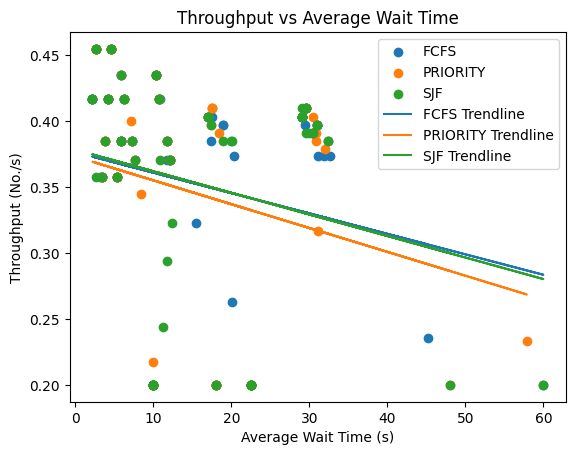

In [38]:
# Plot each group
for policy, policyData in df_grouped:
	plt.scatter(
		x=policyData["Average Wait Time"],
		y=policyData["Throughput"],
		label=policy
	)

# Trendlines
for policy, policyData in df_grouped:
	policydf = df_grouped.get_group(policy)
	x = policydf["Average Wait Time"]
	y = policydf["Throughput"]
	m, b = np.polyfit(x, y, 1)
	plt.plot(x, m*x + b, label=f"{policy} Trendline")

# Labels and legends
plt.legend()
plt.xlabel("Average Wait Time (s)")
plt.ylabel("Throughput (No./s)")
plt.title("Throughput vs Average Wait Time")
plt.show()

## Plot CPU Time vs Throughput

We can do the same for cpu time.

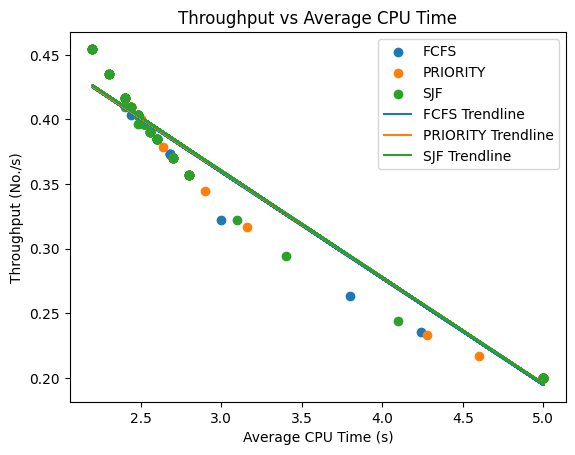

In [39]:
# Plot each group
for policy, policyData in df_grouped:
	plt.scatter(
		x=policyData["Average CPU Time"],
		y=policyData["Throughput"],
		label=policy
	)

# Trendlines
for policy, policyData in df_grouped:
	policydf = df_grouped.get_group(policy)
	x = policydf["Average CPU Time"]
	y = policydf["Throughput"]
	m, b = np.polyfit(x, y, 1)
	plt.plot(x, m*x + b, label=f"{policy} Trendline")

# Labels and legends
plt.legend()
plt.xlabel("Average CPU Time (s)")
plt.ylabel("Throughput (No./s)")
plt.title("Throughput vs Average CPU Time")
plt.show()